In [1]:
from dataset import FLAIRDataset

dataset_train = FLAIRDataset(
    '../datasets/FLAIR',
    'train'
)

dataset_valid = FLAIRDataset(
    '../datasets/FLAIR',
    'valid'
)

print(len(dataset_train.volumes))
print(len(dataset_valid.volumes))
print()
print(len(dataset_train))
print(len(dataset_valid))

100
10

3416
293


In [2]:
batch_size = 16
image_size = 256
epochs = 3
lr = 0.00008

In [3]:
from torch.utils.data import DataLoader

data_loader = {
    'train': DataLoader(
        dataset_train,
        batch_size=batch_size,
        shuffle=False,
    ),
    'valid': DataLoader(
        dataset_valid,
        batch_size=batch_size,
        shuffle=False
    )
}

In [4]:
from utils.loss import bce_dice_score
from torch.optim import Adam
from unet import UNet

model = UNet()

optimizer = Adam(model.parameters(), lr)

Epoch 1/3
----------


100%|██████████| 214/214 [1:27:35<00:00, 24.56s/it]


train Loss: 1.0853



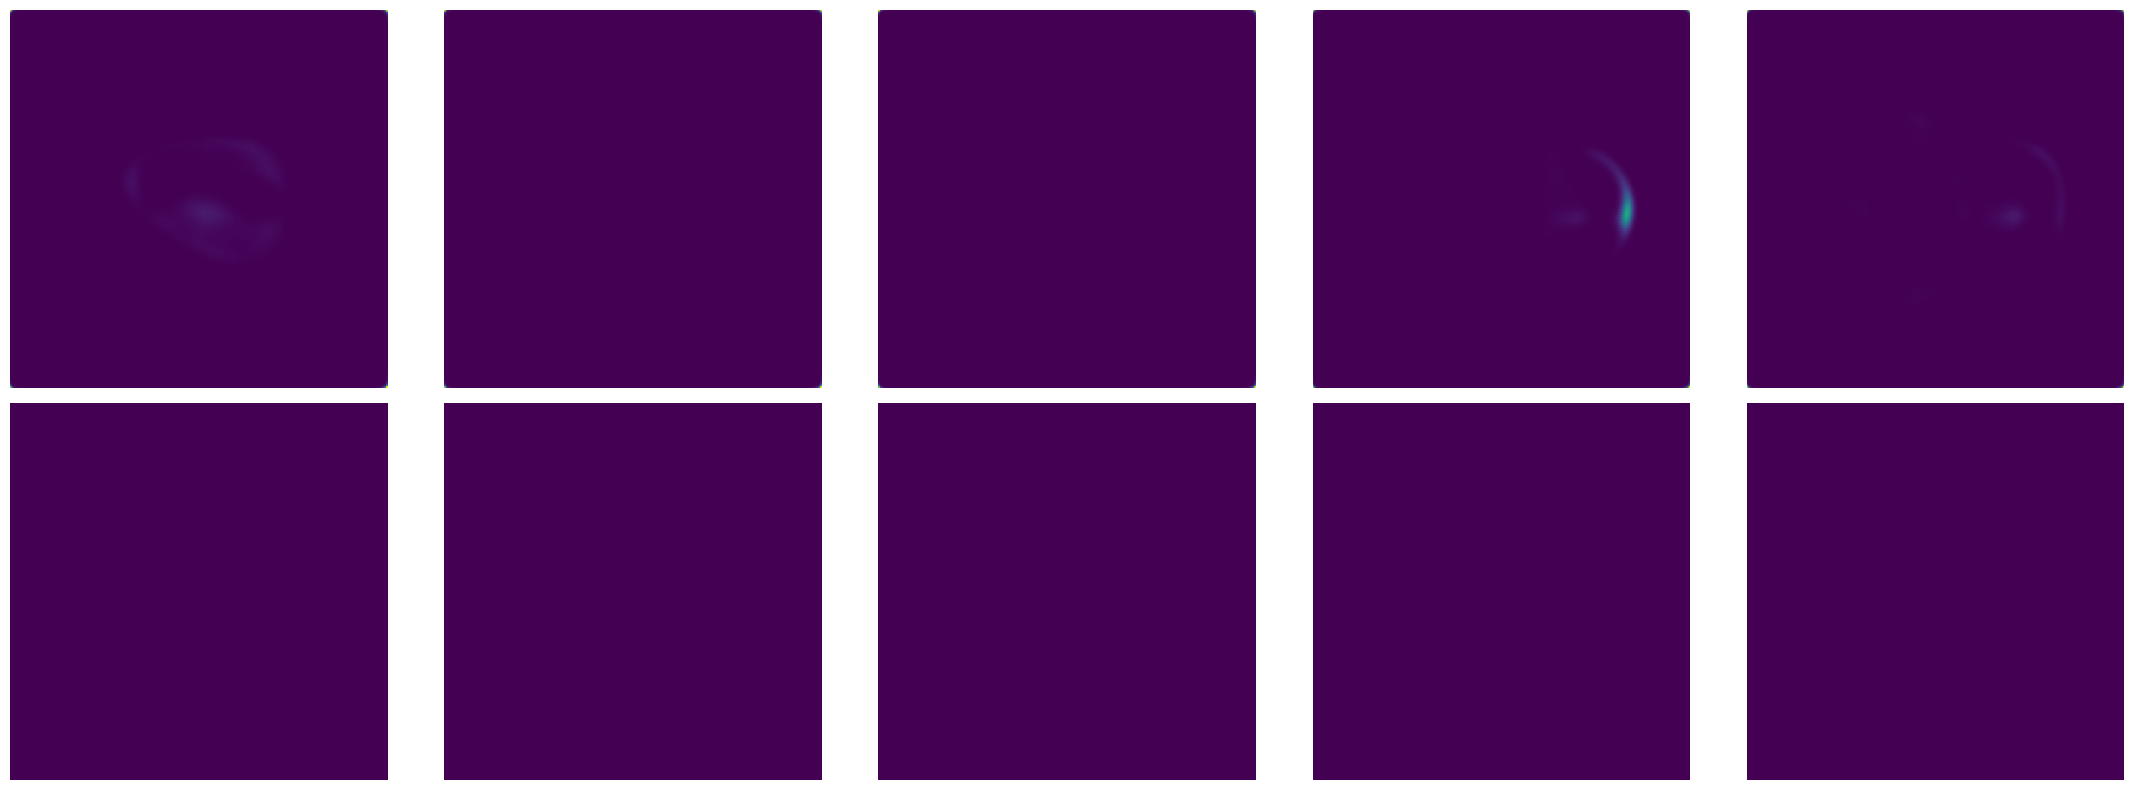

100%|██████████| 19/19 [02:41<00:00,  8.50s/it]


valid Loss: 0.8625



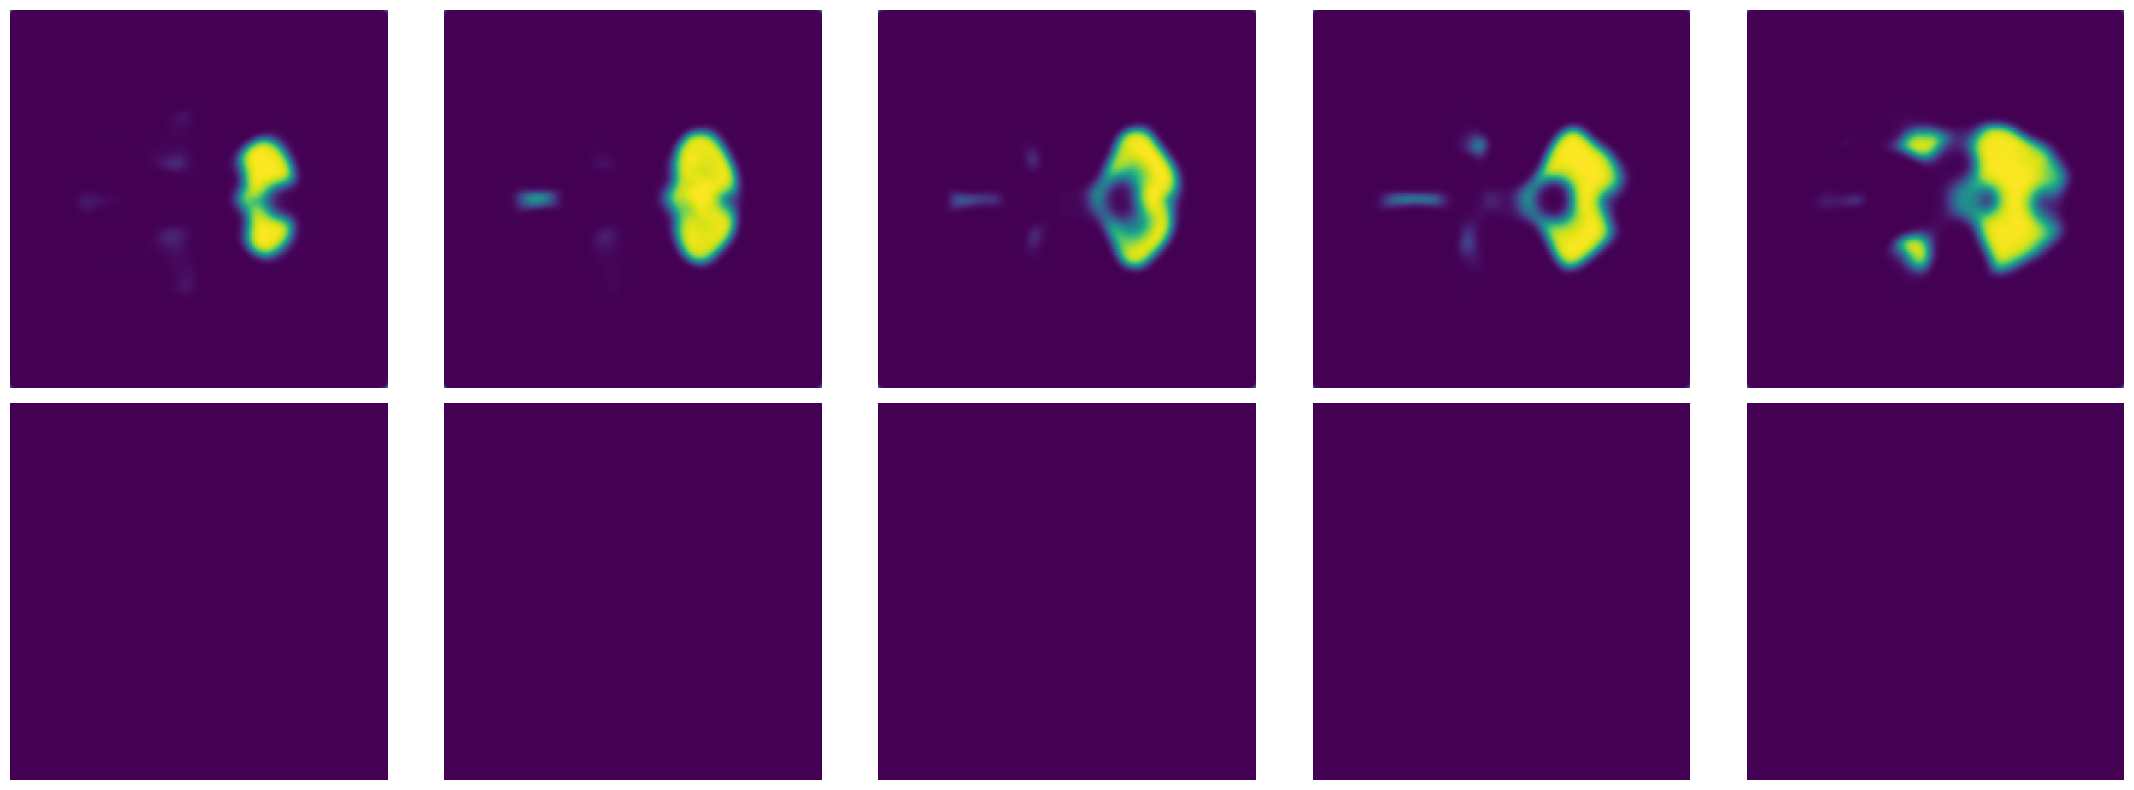

Epoch 2/3
----------


100%|██████████| 214/214 [1:29:51<00:00, 25.19s/it]


train Loss: 0.9018



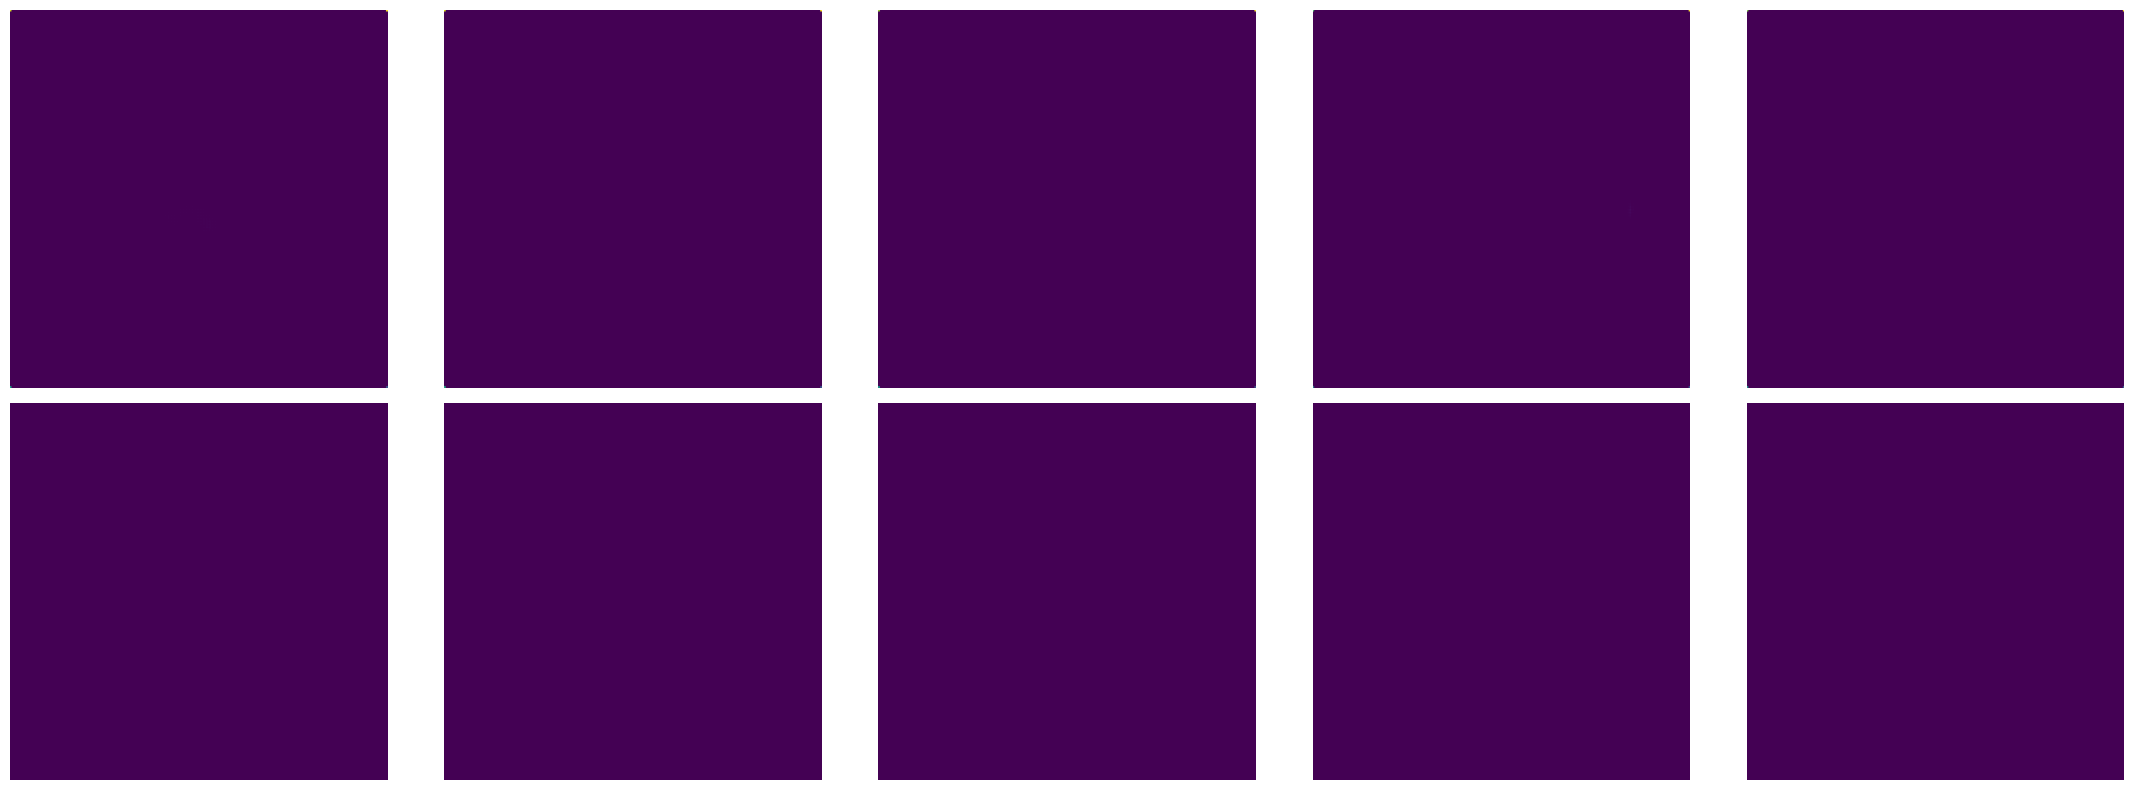

100%|██████████| 19/19 [02:35<00:00,  8.21s/it]


valid Loss: 0.7166



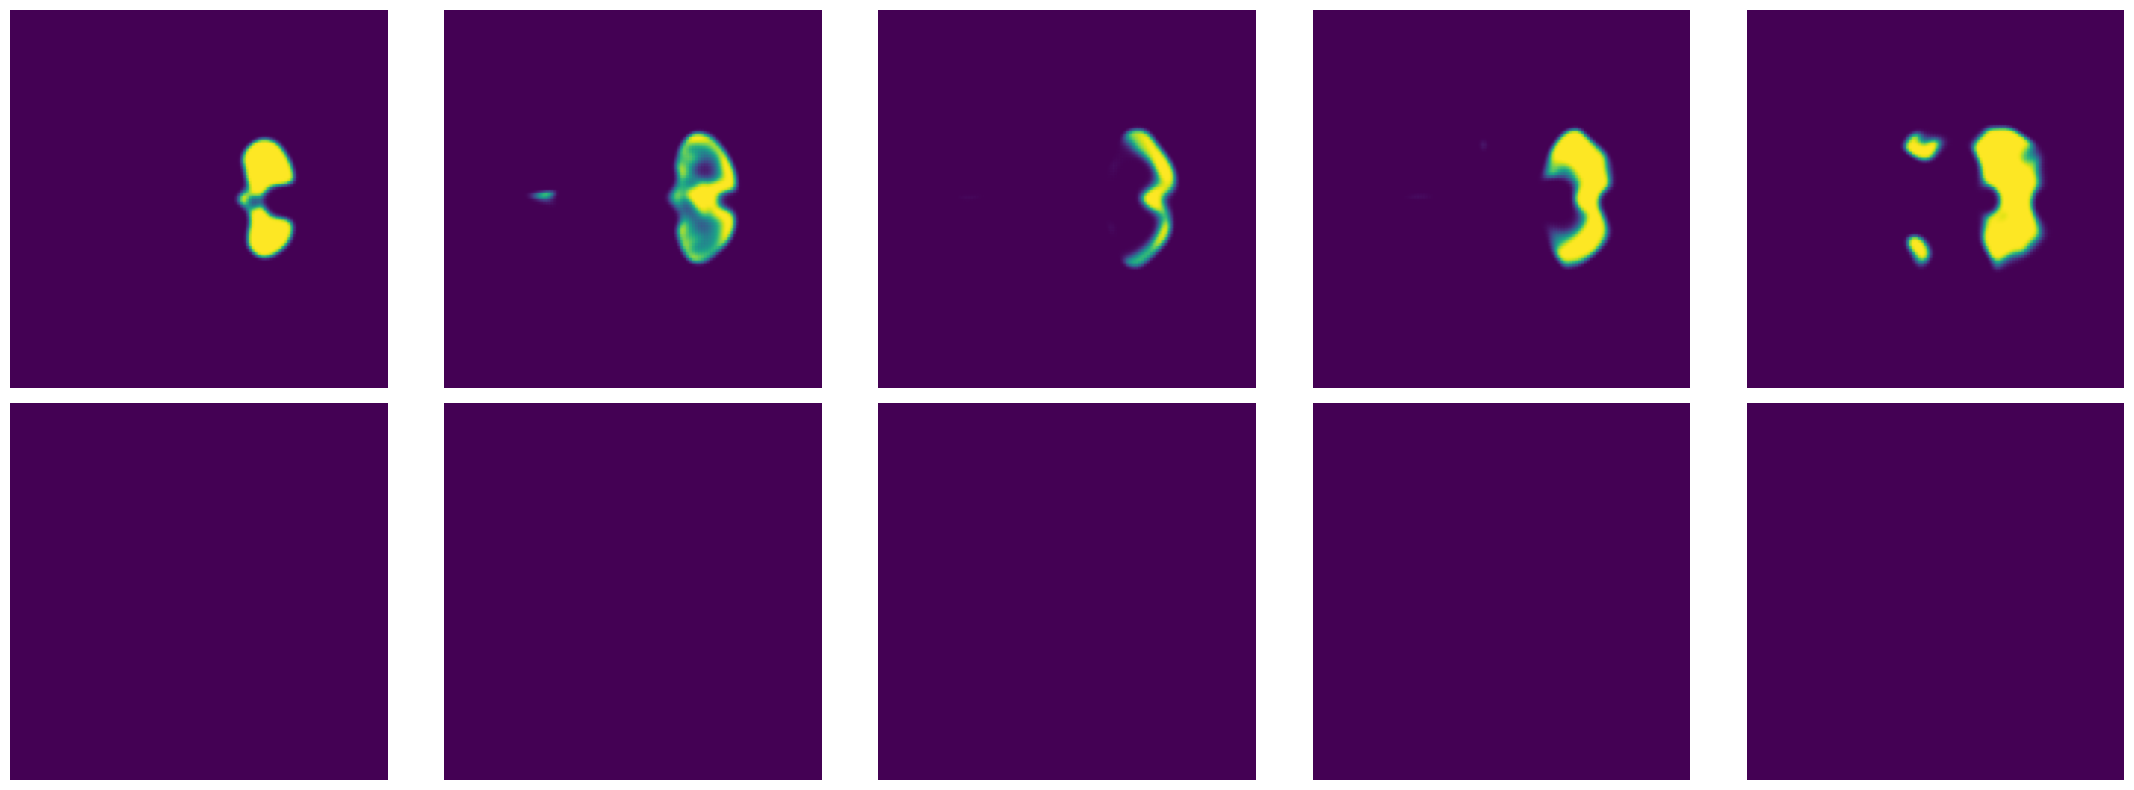

Epoch 3/3
----------


100%|██████████| 214/214 [1:27:21<00:00, 24.49s/it]


train Loss: 0.8773



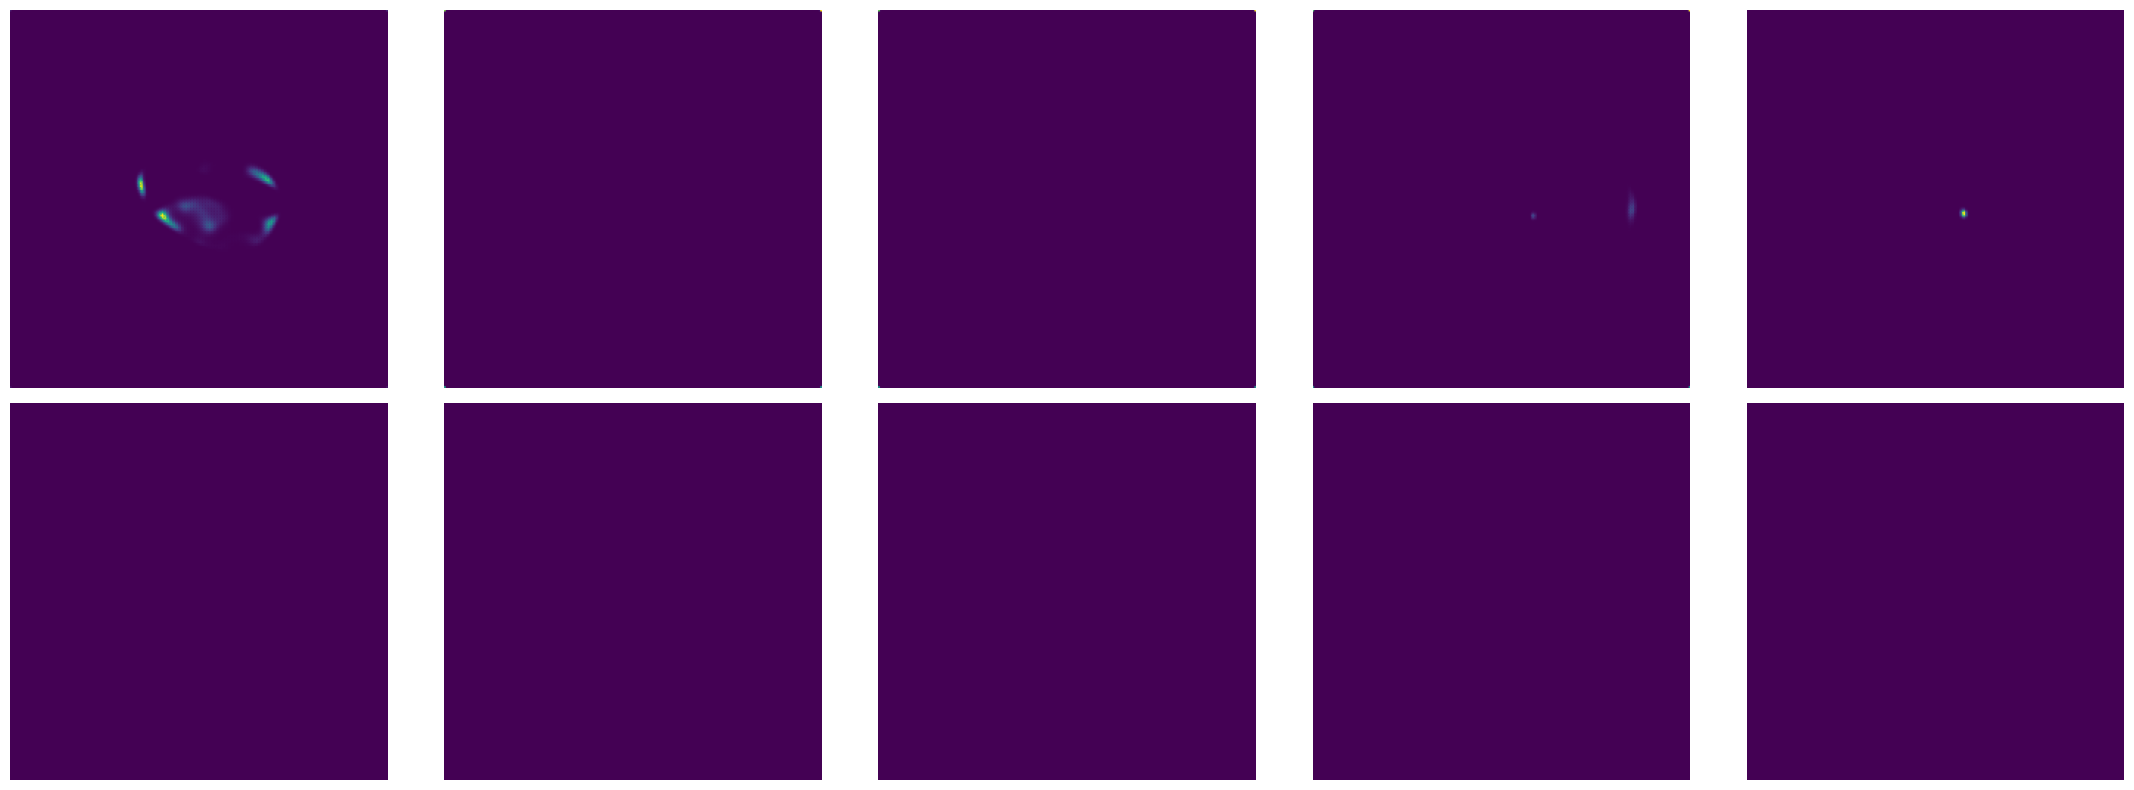

100%|██████████| 19/19 [02:40<00:00,  8.45s/it]


valid Loss: 0.6312



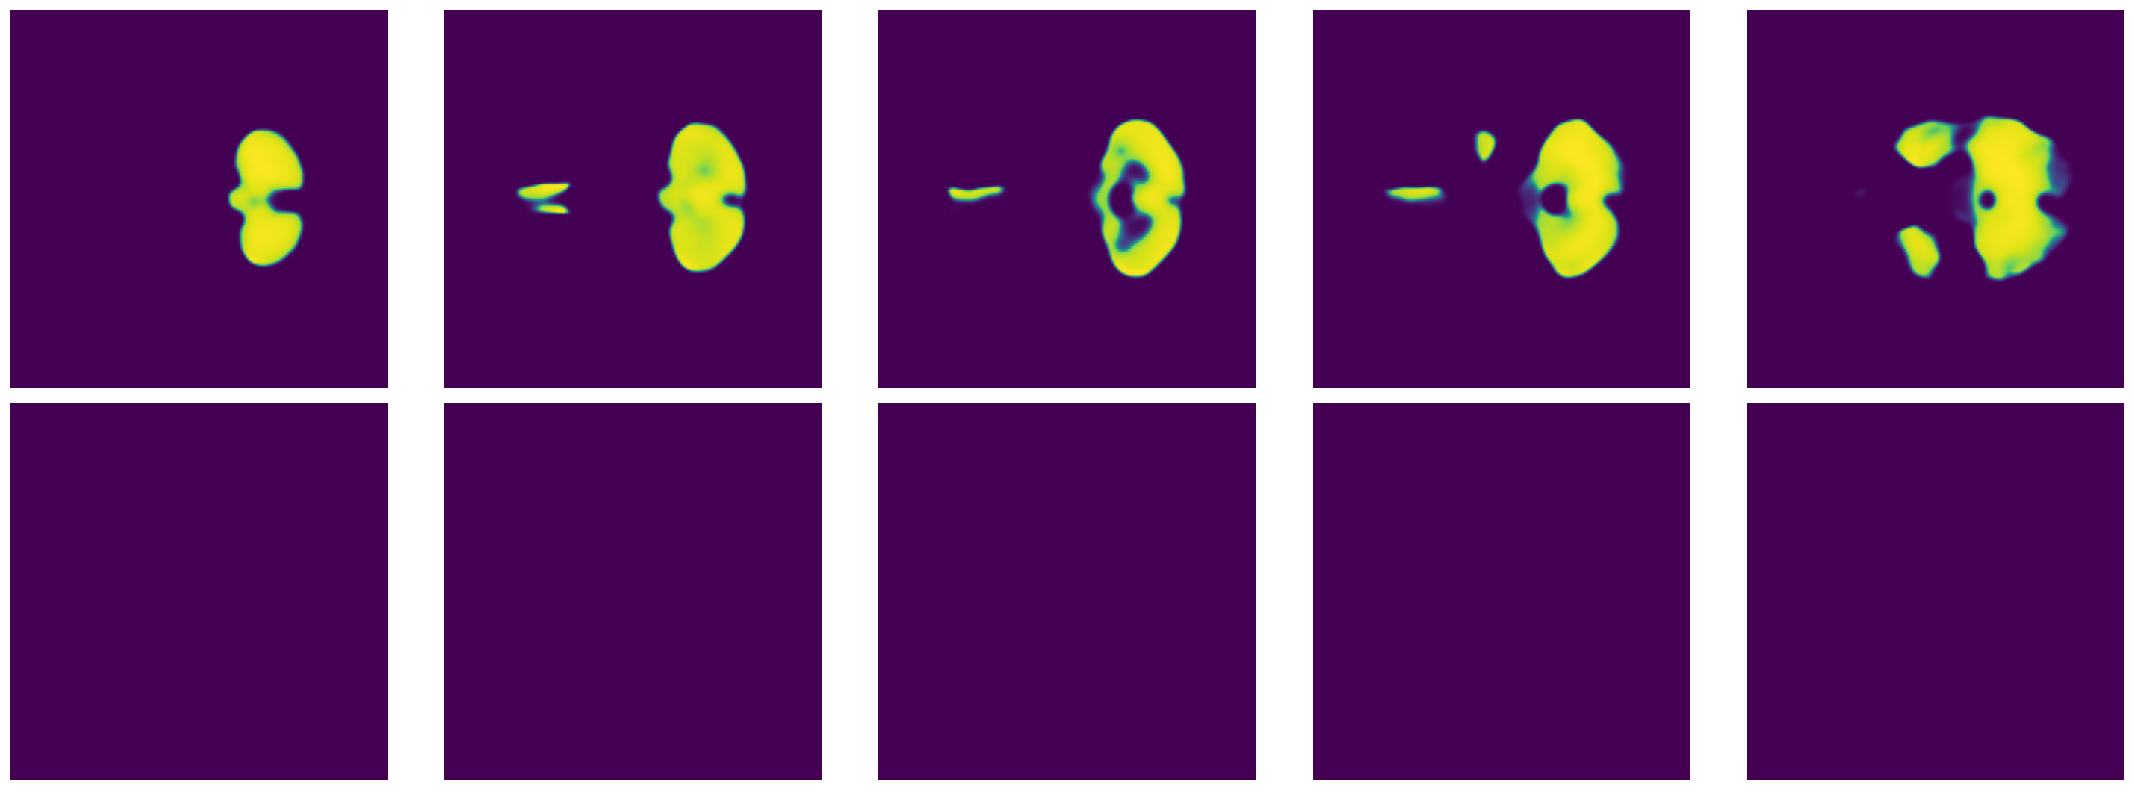

In [5]:
import importlib
from tqdm import tqdm
from utils import visualize

importlib.reload(visualize)

train_loss_curve = []
valid_loss_curve = []

for epoch in range(epochs):
    print("Epoch {}/{}".format(epoch+1, epochs))
    print('-' * 10)

    for phase in ['train', 'valid']:
        if phase == 'train':
            model.train(True)
        else:
            model.train(False)
        
        running_loss = 0.

        # iterate over data
        for step, data in tqdm(enumerate(data_loader[phase]), total=len(data_loader[phase])):
            # retrieve training data
            inputs, masks = data

            # reset the gradients
            optimizer.zero_grad()

            # forward
            y_preds = model(inputs)

            # compute loss
            loss = bce_dice_score(y_preds, masks)
            
            # backward + optimize in training phase
            if phase == 'train':
                loss.backward()
                optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(data_loader[phase])
        print("{} Loss: {:.4f}\n".format(
            phase, epoch_loss
        ))

        if phase == 'train':
            train_loss_curve.append(epoch_loss)
        else:
            valid_loss_curve.append(epoch_loss)
        visualize.visualize_preds(y_preds, masks, epoch)

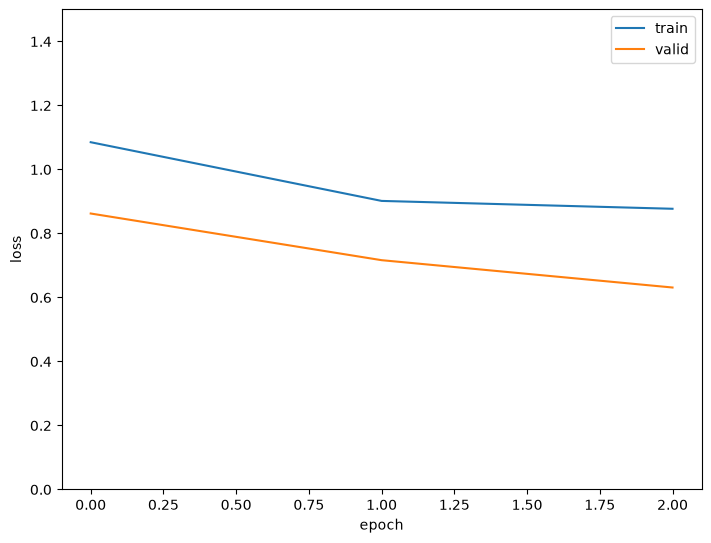

In [9]:
import matplotlib.pyplot as plt

def plot_loss():
    fig = plt.figure()
    fig.subplots_adjust(left=2, right = 3, wspace=0.3, bottom = 2, top = 3)
    ax = plt.axes()

    ax.plot(train_loss_curve, label='train')
    ax.plot(valid_loss_curve, label='valid')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend()

    plt.ylim(0, 1.5)
plot_loss()

In [7]:
import torch

torch.save(model.state_dict(), "models/unet_trained.pth")

In [14]:
inputs, masks = next(iter(data_loader['valid']))
y_preds = model(inputs)

y_preds.shape

torch.Size([16, 1, 256, 256])

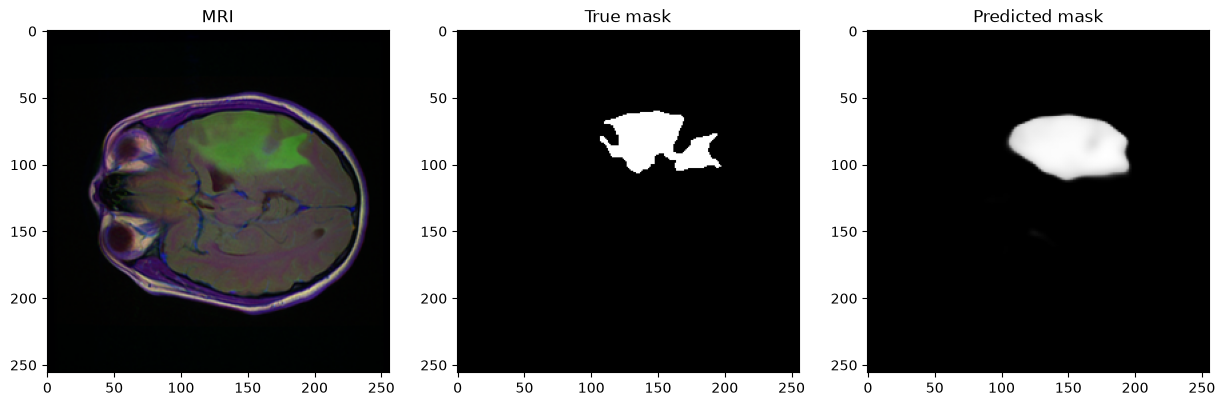

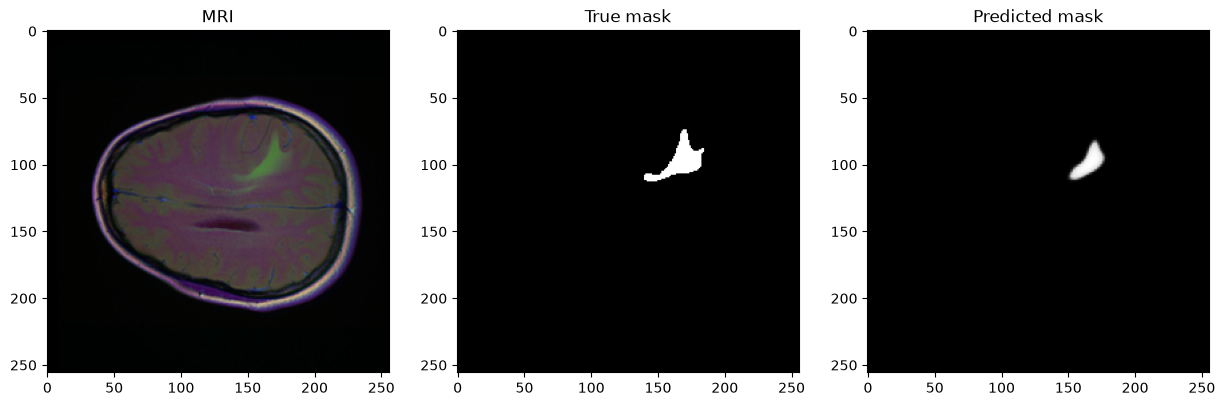

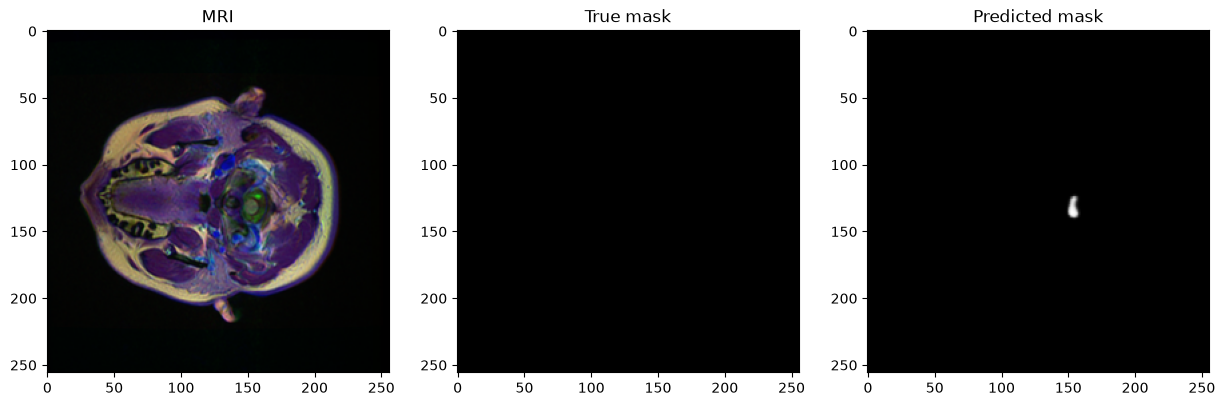

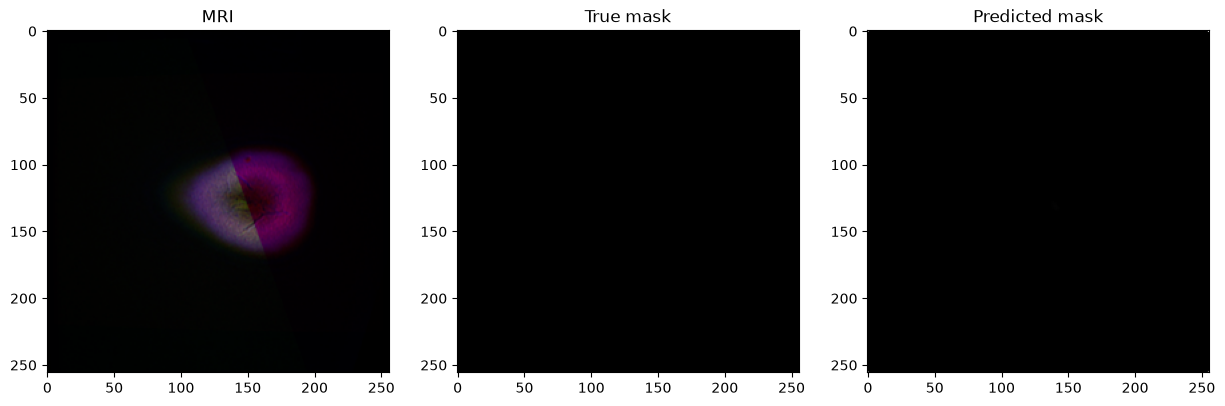

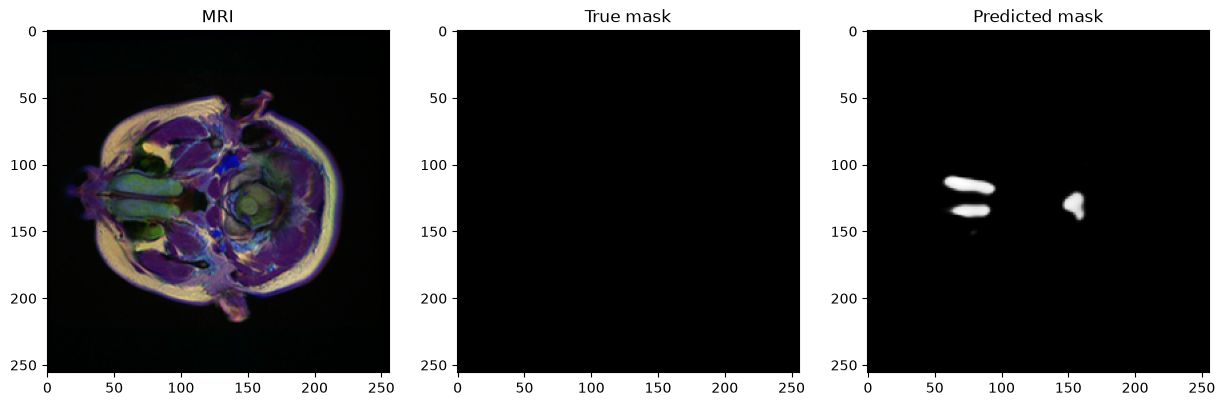

In [26]:
import numpy as np

for idx in [0, 6, 10, 14, 15]:
    fig = plt.figure(figsize=(15, 5))

    y_pred = y_preds[idx].detach()

    # plot MRI
    fig.add_subplot(1, 3, 1)
    plt.imshow(inputs[idx].permute(2, 1, 0))
    plt.title('MRI')

    # plot true mask
    fig.add_subplot(1, 3, 2)
    plt.imshow(masks[idx].permute(2, 1, 0), cmap='gray')
    plt.title('True mask')

    # plot predicted mask
    fig.add_subplot(1, 3, 3)
    plt.imshow(np.transpose(y_pred, (2, 1, 0)), cmap='gray')
    plt.title('Predicted mask')

    plt.show()

/tmp/ipykernel_256941/82716253.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(masks, label='True masks', hist=True, color="#fc0328", ax=ax)
/tmp/ipykernel_256941/82716253.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_preds.detach(), label='Predicted masks', hist=True, color="#0c06c7

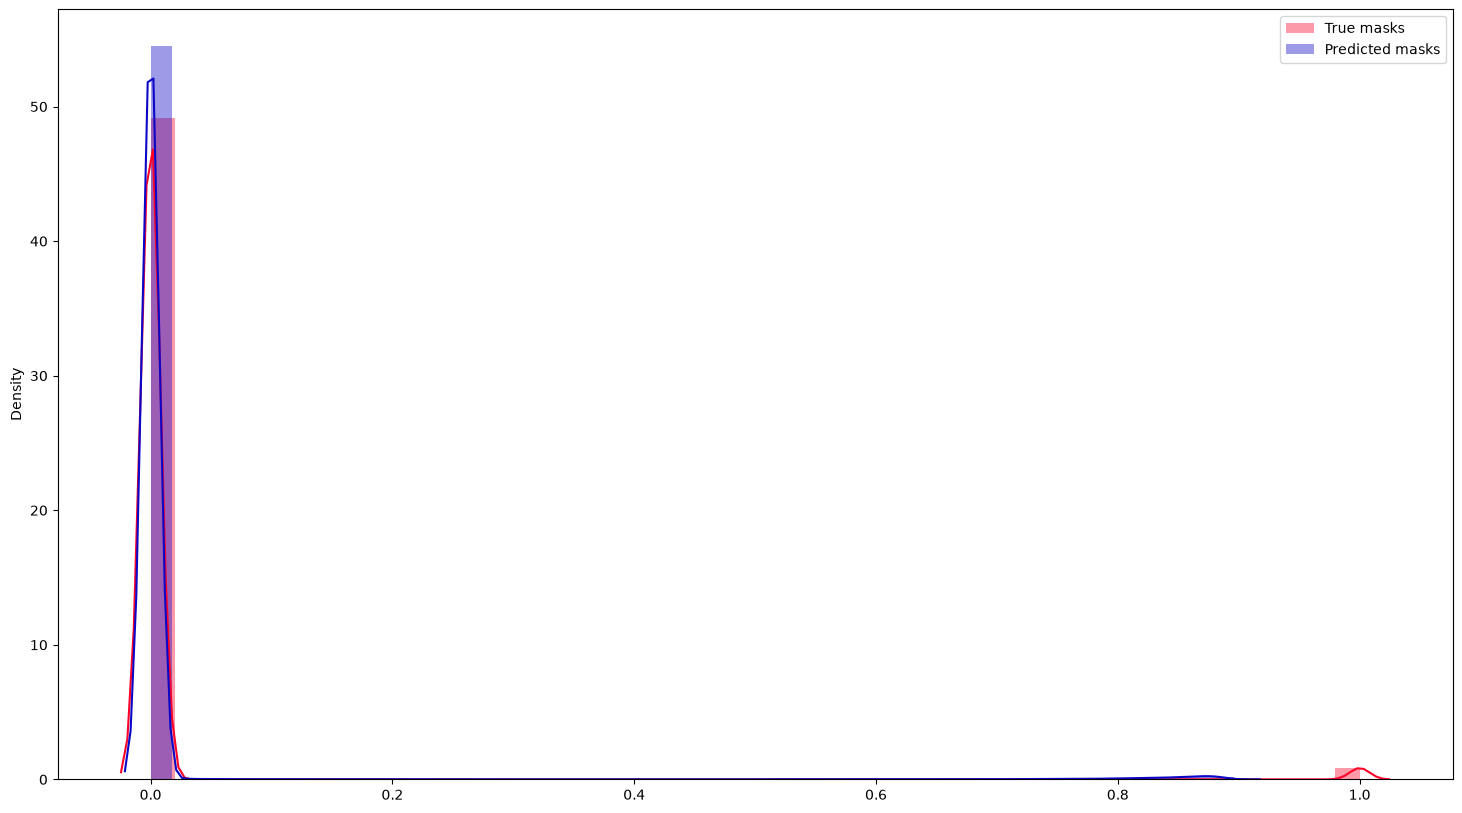

In [28]:
import seaborn as sns

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(18,10))

sns.distplot(masks, label='True masks', hist=True, color="#fc0328", ax=ax)
sns.distplot(y_preds.detach(), label='Predicted masks', hist=True, color="#0c06c7", ax=ax)

ax.legend(loc='upper right', prop={'size': 10})